<a href="https://colab.research.google.com/github/MEY1337/deep-learning-practice/blob/main/02_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6장. 로지스틱 회귀 모델: 참 거짓 판단하기

## 5. 텐서플로에서 실행하는 로지스틱 회귀 모델

### 1.환경 준비

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [2]:
x = np.array([2, 4, 6, 8, 10, 12, 14])
y = np.array([0, 0, 0, 1, 1, 1, 1])

### 3. 모델 실행

In [4]:
model = Sequential()
model.add(Dense(1, input_dim=1, activation='sigmoid'))

# 교차 엔트로피 오차 함수를 이용하기 위하여 'binary_crossentropy'로 설정합니다.
model.compile(optimizer='sgd' ,loss='binary_crossentropy')
model.fit(x, y, epochs=2000, verbose=1)  #verbose=1 진행 화면 출력, verbose=0 진행 화면 출력 안함.

Epoch 1/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step - loss: 0.6980
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.6824
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.6678
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.6541
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.6413
Epoch 6/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.6295
Epoch 7/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.6186
Epoch 8/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.6087
Epoch 9/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5998
Epoch 10/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5917
Epoch 11/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5845
Epoch 12/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.5781
Epoch 13/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5725
Epoch 14/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.5676
Epoch 15/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5634
Epo

### 4. 모델 테스트

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


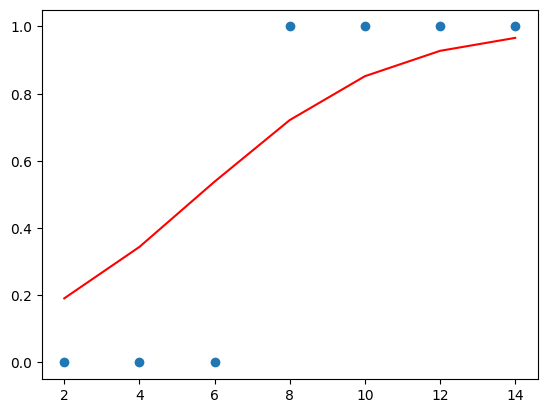

In [5]:
# 그래프로 확인해 봅니다.

plt.scatter(x, y)
plt.plot(x, model.predict(x),'r')
plt.show()

In [6]:
import tensorflow as tf

# 임의의 학습 시간을 집어넣어 합격 예상 확률을 예측해 보겠습니다.

hour = 7
#prediction = model.predict([hour]) #텐서플로 2.9.0 까지만 가능

input_data = tf.constant([[hour]])
prediction = model.predict(input_data)[0][0]


print("%.f시간을 공부할 경우, 합격 예상 확률은 %.01f%%입니다" % (hour, prediction * 100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
7시간을 공부할 경우, 합격 예상 확률은 63.5%입니다


# 실습 문제

epoch, loss type 등을 바꿔서 실행해보고 결과를 비교 후 이유를 적어보세요

- 파라미터 변경사항 작성
- 결과 비교 작성
- 이유 작성

**기본 설정**: optimizer='sgd', loss='binary_crossentropy', epochs=2000

**비교 대상**: epochs=500, epochs=3000, optimizer='adam'

**epochs의 경우**: 수치를 낮게 설정할수록 loss 감소량 변화 없음. 높게 설정할수록 감소량 증가.

**optimizer의 경우**: adam으로 변경했을 때는 빠르게 수렴, sgd 보다 초기 학습 속도가 빠르며 안정적인 결과값 획득.

**결론**: epoch는 모델이 데이터를 충분히 학습하는 데 중요한 역할을 하며, optimizer는 학습 속도와 안정성에 영향을 준다. 따라서 적절한 epoch와 optimizer를 선택하는 것이 모델의 성능 향상에 중요하다는 것을 확인할 수 있었다.